In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from omegaconf import OmegaConf 
import tqdm

import what_where as ww


In [3]:
dataset_path = ww.utils.DATA_DIR / "behavioral_datasets" / "behavioral_experiment"
images_path = dataset_path / "images"
dataset_df = pd.read_csv(dataset_path / "behavioral_dataset.csv")
dataset_df

,trial,what,where_x,where_y,noise,n_distractors
0,0,5,0.197744,-0.093974,0.051924,1
1,1,8,0.289351,0.336740,0.039317,8
2,2,5,0.211184,0.334267,0.005226,3
3,3,0,-0.081587,-0.349732,0.022040,3
4,4,8,0.002232,-0.099996,0.186451,8
...,...,...,...,...,...,...
395,395,4,0.216024,0.123253,0.036197,4
396,396,3,-0.307019,0.277783,0.193634,1
397,397,8,0.069374,-0.361485,0.072410,8
398,398,1,-0.315223,-0.309640,0.092594,3


In [4]:
EXPERIMENT_TYPE = "flexible" # choose between "fixed" and "flexible"
cfg_main = ww.utils.load_config(f"config_vcs_{EXPERIMENT_TYPE}")

EPOCH = cfg_main.train.epochs

if EXPERIMENT_TYPE == "flexible":
    ENERGY_COSTS = ww.utils.get_energy_costs(cfg_main)
    print(len(ENERGY_COSTS))
    print(ENERGY_COSTS)

100
[-6.0, -6.06, -6.12, -6.18, -6.24, -6.3, -6.36, -6.42, -6.48, -6.55, -6.61, -6.67, -6.73, -6.79, -6.85, -6.91, -6.97, -7.03, -7.09, -7.15, -7.21, -7.27, -7.33, -7.39, -7.45, -7.52, -7.58, -7.64, -7.7, -7.76, -7.82, -7.88, -7.94, -8.0, -8.06, -8.12, -8.18, -8.24, -8.3, -8.36, -8.42, -8.48, -8.55, -8.61, -8.67, -8.73, -8.79, -8.85, -8.91, -8.97, -9.03, -9.09, -9.15, -9.21, -9.27, -9.33, -9.39, -9.45, -9.52, -9.58, -9.64, -9.7, -9.76, -9.82, -9.88, -9.94, -10.0, -10.06, -10.12, -10.18, -10.24, -10.3, -10.36, -10.42, -10.48, -10.55, -10.61, -10.67, -10.73, -10.79, -10.85, -10.91, -10.97, -11.03, -11.09, -11.15, -11.21, -11.27, -11.33, -11.39, -11.45, -11.52, -11.58, -11.64, -11.7, -11.76, -11.82, -11.88, -11.94, -12.0]


cuda:0 torch.Size([400, 1, 64, 64])
tensor(-0.5004, device='cuda:0') tensor(0.5288, device='cuda:0')


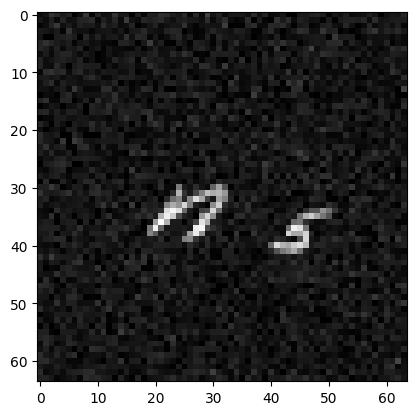

In [5]:
# load images as pytorch tensors from png
def load_image(image_path):
    image = plt.imread(image_path)
    image = torch.from_numpy(image)
    image = image.unsqueeze(0)
    return image

images = []
for i in range(dataset_df.shape[0]):
    image_path = images_path / f"image_{i}.png"
    image = load_image(image_path)
    images.append(image)

images = torch.cat(images, dim=0)
images = images.unsqueeze(1) # add chanel dimension
images = images.to("cuda")
transform = ww.utils.get_transforms(cfg_main)[1] # only validation transform
for i in range(images.shape[0]):
    images[i] = transform(images[i])

print(images.device, images.shape)
# show some images
plt.imshow(images[0].squeeze().cpu().numpy(), cmap="gray")
print(images[0].mean(), images[0].std())

In [6]:

checkpoints_path = ww.utils.CHECKPOINTS_DIR / cfg_main.dataset.name / cfg_main.experiment.name

run_paths = []
model_names = [entry.name for entry in (checkpoints_path).iterdir() if entry.is_dir()]
for model_name in model_names:
    runs = [entry.name for entry in (checkpoints_path / model_name).iterdir() if entry.is_dir()]
    for run in runs:
        path = checkpoints_path / model_name / run
        print(path)
        run_paths.append(path)

print(len(run_paths))

/home/eivinas/dev/what-where/checkpoints/vcs/journal_flexible/baseline/instance3
/home/eivinas/dev/what-where/checkpoints/vcs/journal_flexible/baseline/instance2
/home/eivinas/dev/what-where/checkpoints/vcs/journal_flexible/baseline/instance4
/home/eivinas/dev/what-where/checkpoints/vcs/journal_flexible/baseline/instance1
/home/eivinas/dev/what-where/checkpoints/vcs/journal_flexible/baseline/instance0
/home/eivinas/dev/what-where/checkpoints/vcs/journal_flexible/ean_full/instance3
/home/eivinas/dev/what-where/checkpoints/vcs/journal_flexible/ean_full/instance2
/home/eivinas/dev/what-where/checkpoints/vcs/journal_flexible/ean_full/instance4
/home/eivinas/dev/what-where/checkpoints/vcs/journal_flexible/ean_full/instance1
/home/eivinas/dev/what-where/checkpoints/vcs/journal_flexible/ean_full/instance0
/home/eivinas/dev/what-where/checkpoints/vcs/journal_flexible/ean_space/instance3
/home/eivinas/dev/what-where/checkpoints/vcs/journal_flexible/ean_space/instance2
/home/eivinas/dev/what-whe

In [7]:


def get_predictions(cfg, model, dataloader, predictions_path, energy_cost=None):
    if EXPERIMENT_TYPE == "fixed": # setting the energy cost based on the checkpoint
        energy_cost = cfg.train.energy.cost.min

    n_passes = cfg.model.n_passes
    n_images = len(dataloader.dataset)
    n_classes = cfg.dataset.what.size
    heatmap_size = cfg.dataset.where.size

    n_inference_samples = cfg_main.analysis.model.n_inference_samples

    what_predictions = np.zeros((n_inference_samples, n_images,  n_passes, n_classes))
    where_predictions = np.zeros((n_inference_samples, n_images, n_passes, heatmap_size, heatmap_size))
    energies_ap = np.zeros((n_inference_samples, n_images, n_passes))
    energies_st = np.zeros((n_inference_samples, n_images, n_passes))

    with torch.no_grad():
        for i in range(n_inference_samples):
            start_i = 0 # indexing into numpy array given that we don't know the batch size (last one is different)

            for j, images in enumerate(dataloader):
                images = images.to(device) 
                batch_size = images.size(0)
                # we pass to the initialization of the hidden state (needs to be (batch_size, 1))
                energy_cost_batch = torch.tensor(energy_cost, dtype=torch.float32).to(device).repeat(batch_size, 1)

                # prev_out = None
                end_i = start_i + batch_size

                out = model(images, energy_cost_batch, n_passes, noise_anneal=1.0)

                for t in range(n_passes):
                    # print(f"Run {run_path}, sample {i+1}/{n_inference_samples}, batch {j+1}, pass {t+1}/{n_passes}", end="\r")
                    # prev_out = out

                    what_predictions[i, start_i:end_i, t] = torch.softmax(out[t]["prediction"]["what"], dim=1).detach().cpu().numpy()
                    where_predictions[i, start_i:end_i, t] = torch.softmax(out[t]["prediction"]["where"], dim=1).reshape(batch_size, heatmap_size, heatmap_size).detach().cpu().numpy()

                    energy_use = ww.utils.get_energy_use(cfg, out, t, device)

                    energy_ap = energy_use["ap"].detach().cpu().numpy()
                    energy_st = energy_use["st"].detach().cpu().numpy()

                    if np.isnan(energy_ap).any() or np.isnan(energy_st).any():
                        raise ValueError(f"energy is nan in run {predictions_path}, sample {i}, image {start_i} to {end_i}")

                    energies_ap[i, start_i:end_i, t] = energy_ap
                    energies_st[i, start_i:end_i, t] = energy_st
                start_i = end_i

        np.save(predictions_path / "what_predictions.npy", what_predictions)
        np.save(predictions_path / "where_predictions.npy", where_predictions)
        np.save(predictions_path / "energies_ap.npy", energies_ap)
        np.save(predictions_path / "energies_st.npy", energies_st)

dataloader = torch.utils.data.DataLoader(images, batch_size=len(images), shuffle=False)
# dataloader = torch.utils.data.DataLoader(images, batch_size=2, shuffle=False)
# for path in reversed(run_paths):
for path in tqdm.tqdm(run_paths):
    print(path)

    # loading the checkpoint
    try:
        checkpoint_path = ww.utils.get_checkpoint_path_from_dir(path, printing=False)
        checkpoint = torch.load(checkpoint_path, weights_only=False)

        if EPOCH != checkpoint["epoch"]:
            print(f"WARN: checkpoint epoch {checkpoint['epoch']} does not match requested epoch {EPOCH} for {path}")

    except Exception as e:
        print(e)
        print(f"WARN: no checkpoint found for {path} or corrupted checkpoint")


    # getting the configuration associated with the training run
    cfg = OmegaConf.create(checkpoint["config"])

    # considering all spikes when evaluting energy used
    # (this is set to 0.1 during training to speed things up)
    cfg.train.energy.st_sample_ratio = 1.0

    device = 'cuda'

    model = ww.model.Model(cfg)
    model.to(device)

    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    if EXPERIMENT_TYPE == "flexible":
        # for energy_cost in tqdm.tqdm(ENERGY_COSTS):
        for energy_cost in ENERGY_COSTS:
            # print(path, energy_cost)
            predictions_path = path / f"predictions_{energy_cost:.2f}"
            predictions_path.mkdir(exist_ok=True, parents=True)
            if predictions_path.exists() and any(predictions_path.iterdir()):
                # print(f"Predictions already exist for {predictions_path}, skipping...")
                continue
            get_predictions(cfg, model, dataloader, predictions_path, energy_cost=energy_cost)
    else: # fixed
        predictions_path = path / "predictions"
        if predictions_path.exists() and any(predictions_path.iterdir()):
            # print(f"Predictions already exist for {predictions_path}, skipping...")
            continue

        get_predictions(cfg, model, dataloader, predictions_path)

  0%|          | 0/25 [00:00<?, ?it/s]

/home/eivinas/dev/what-where/checkpoints/vcs/journal_flexible/baseline/instance3


  4%|▍         | 1/25 [00:01<00:46,  1.95s/it]

/home/eivinas/dev/what-where/checkpoints/vcs/journal_flexible/baseline/instance2


  8%|▊         | 2/25 [00:03<00:36,  1.59s/it]

...

 92%|█████████▏| 23/25 [1:58:13<14:29, 434.52s/it]

/home/eivinas/dev/what-where/checkpoints/vcs/journal_flexible/ean_global/instance1


 96%|█████████▌| 24/25 [2:05:29<07:14, 434.84s/it]

/home/eivinas/dev/what-where/checkpoints/vcs/journal_flexible/ean_global/instance0


100%|██████████| 25/25 [2:12:44<00:00, 318.57s/it]


In [9]:

def get_accuracy_df(cfg_checkpoing, run_path, energy_cost=None):

    if EXPERIMENT_TYPE == "fixed": # setting the energy cost based on the checkpoint
        energy_cost = cfg_checkpoint.train.energy.cost.min

    # predictions_path = run_path / "predictions" / f"energy_{energy_cost}"
    if EXPERIMENT_TYPE == "fixed":
        predictions_path = run_path / "predictions"
    else: # flexible
        predictions_path = run_path / f"predictions_{energy_cost:.2f}"

    # check if predictions exist
    if not predictions_path.exists():
        print(f"ERROR: predictions do not exist for {run_path}")
        return

    what_predictions = np.load(predictions_path / "what_predictions.npy")
    where_predictions = np.load(predictions_path / "where_predictions.npy")
    energies_ap = np.load(predictions_path / "energies_ap.npy")
    energies_st = np.load(predictions_path / "energies_st.npy")

    # print(what_predictions.shape, where_predictions.shape, energies_ap.shape, energies_st.shape)

    n_inference_samples = cfg_main.analysis.model.n_inference_samples # just one actually

    _, n_images, n_passes, n_classes = what_predictions.shape
    what_corrects = np.zeros((n_inference_samples, n_images, n_passes))

    where_x_responses = np.zeros((n_inference_samples, n_images, n_passes))
    where_y_responses = np.zeros((n_inference_samples, n_images, n_passes))
    where_x_gt = np.zeros((n_inference_samples, n_images, n_passes))
    where_y_gt = np.zeros((n_inference_samples, n_images, n_passes))

    confidences = np.zeros((n_inference_samples, n_images, n_passes)) # this is the max probability of the what prediction
    what_entropies = np.zeros((n_inference_samples, n_images, n_passes)) # this is the entropy of the what prediction
    where_entropies = np.zeros((n_inference_samples, n_images, n_passes)) # this is the entropy of the where prediction
    
    samples = []
    images = []
    ts = []

    for i in range(n_inference_samples):

        for j in range(n_images):
            what_ground_truth = dataset_df["what"][j]
            where_ground_truth = np.array([dataset_df["where_x"][j], dataset_df["where_y"][j]], dtype=float)

            for t in range(n_passes):
                # what
                what_corrects[i, j, t] = np.argmax(what_predictions[i, j, t]) == what_ground_truth

                # where
                where_max_index = np.argmax(where_predictions[i, j, t])
                y, x = divmod(where_max_index, where_predictions.shape[-1])
                y = where_predictions.shape[-1] - y
                where_prediction = np.array([x, y], dtype=float)
                where_prediction /= where_predictions.shape[-1] # normalize to [0, 1]
                where_prediction -= 0.5 # center around 0

                where_x_responses[i, j, t] = where_prediction[0]
                where_y_responses[i, j, t] = where_prediction[1]
                where_x_gt[i, j, t] = where_ground_truth[0]
                where_y_gt[i, j, t] = where_ground_truth[1]

                confidences[i, j, t] = np.max(what_predictions[i, j, t])
                what_entropies[i, j, t] = -np.sum(what_predictions[i, j, t] * np.log(what_predictions[i, j, t]))
                where_entropies[i, j, t] = -np.sum(where_predictions[i, j, t] * np.log(where_predictions[i, j, t]))

                samples.append(i)
                images.append(j)
                ts.append(t)

    df_shape = n_inference_samples * n_images * n_passes

    df = pd.DataFrame({
        "dataset_index" : images,
        "sample" : samples,
        "t" : ts,

        "what_correct": what_corrects.reshape(df_shape),

        "where_x_response" :  where_x_responses.reshape(df_shape),
        "where_y_response" :  where_y_responses.reshape(df_shape),
        "where_x_gt" :  where_x_gt.reshape(df_shape),
        "where_y_gt" :  where_y_gt.reshape(df_shape),


        "confidence": confidences.reshape(df_shape),
        "what_entropy": what_entropies.reshape(df_shape),
        "where_entropy": where_entropies.reshape(df_shape),
        "energy_ap" : energies_ap.reshape(df_shape),
        "energy_st" : energies_st.reshape(df_shape),

        })
    
    df["model"] = cfg_checkpoint.model.name
    df["energy_cost"] = energy_cost
    df["instance"] = cfg_checkpoint.train.instance
    # df["early_stopping"] = False

    for element in cfg_checkpoint.checkpoint_elements:
        df[element] = ww.utils.get_config_entry(cfg_checkpoint, element)

    return df

# map function from run_paths to df s
accuracy_dfs = []
for run_path in run_paths:
    try:
        checkpoints_path = ww.utils.get_checkpoint_path_from_dir(run_path)
        checkpoint = torch.load(checkpoints_path, weights_only=False)
    except Exception:
        print(f"WARN: no checkpoint found for {run_path} or corrupted checkpoint")
        continue

    cfg_checkpoint = OmegaConf.create(checkpoint["config"])
    if EXPERIMENT_TYPE == "flexible":
        for energy_cost in ENERGY_COSTS:
            print(f"Getting accuracy for {run_path} with energy cost {energy_cost}")
            df = get_accuracy_df(cfg_checkpoint, run_path, energy_cost=energy_cost)
            accuracy_dfs.append(df)
    else: # fixed
        df = get_accuracy_df(cfg_checkpoint, run_path)
        accuracy_dfs.append(df)



checkpoint:  /home/eivinas/dev/what-where/checkpoints/vcs/journal_flexible/baseline/instance3/checkpoint_200.pth 

Getting accuracy for /home/eivinas/dev/what-where/checkpoints/vcs/journal_flexible/baseline/instance3 with energy cost -6.0
Getting accuracy for /home/eivinas/dev/what-where/checkpoints/vcs/journal_flexible/baseline/instance3 with energy cost -6.06
Getting accuracy for /home/eivinas/dev/what-where/checkpoints/vcs/journal_flexible/baseline/instance3 with energy cost -6.12
Getting accuracy for /home/eivinas/dev/what-where/checkpoints/vcs/journal_flexible/baseline/instance3 with energy cost -6.18
Getting accuracy for /home/eivinas/dev/what-where/checkpoints/vcs/journal_flexible/baseline/instance3 with energy cost -6.24
Getting accuracy for /home/eivinas/dev/what-where/checkpoints/vcs/journal_flexible/baseline/instance3 with energy cost -6.3
Getting accuracy for /home/eivinas/dev/what-where/checkpoints/vcs/journal_flexible/baseline/instance3 with energy cost -6.36
Getting accu

In [10]:
accuracy_dfs

[      dataset_index  sample  t  what_correct  where_x_response  \
 0                 0       0  0           0.0               0.2   
 1                 0       0  1           1.0               0.2   
 2                 0       0  2           1.0               0.2   
 3                 0       0  3           1.0               0.3   
 4                 1       0  0           0.0               0.3   
 ...             ...     ... ..           ...               ...   
 1595            398       0  3           1.0              -0.3   
 1596            399       0  0           0.0               0.0   
 1597            399       0  1           0.0               0.3   
 1598            399       0  2           0.0               0.3   
 1599            399       0  3           0.0               0.3   
 
       where_y_response  where_x_gt  where_y_gt  confidence  what_entropy  \
 0                 -0.1    0.197744   -0.093974    0.269086      1.989729   
 1                 -0.1    0.197744   -0

In [11]:
# concatenate all dfs
model_df = pd.concat(accuracy_dfs, ignore_index=True)

# check energy cost uniques
print(model_df["energy_cost"].unique())
print(model_df["sample"].unique())

model_df

[ -6.    -6.06  -6.12  -6.18  -6.24  -6.3   -6.36  -6.42  -6.48  -6.55
  -6.61  -6.67  -6.73  -6.79  -6.85  -6.91  -6.97  -7.03  -7.09  -7.15
  -7.21  -7.27  -7.33  -7.39  -7.45  -7.52  -7.58  -7.64  -7.7   -7.76
  -7.82  -7.88  -7.94  -8.    -8.06  -8.12  -8.18  -8.24  -8.3   -8.36
  -8.42  -8.48  -8.55  -8.61  -8.67  -8.73  -8.79  -8.85  -8.91  -8.97
  -9.03  -9.09  -9.15  -9.21  -9.27  -9.33  -9.39  -9.45  -9.52  -9.58
  -9.64  -9.7   -9.76  -9.82  -9.88  -9.94 -10.   -10.06 -10.12 -10.18
 -10.24 -10.3  -10.36 -10.42 -10.48 -10.55 -10.61 -10.67 -10.73 -10.79
 -10.85 -10.91 -10.97 -11.03 -11.09 -11.15 -11.21 -11.27 -11.33 -11.39
 -11.45 -11.52 -11.58 -11.64 -11.7  -11.76 -11.82 -11.88 -11.94 -12.  ]
[0]


,dataset_index,sample,t,what_correct,where_x_response,where_y_response,where_x_gt,where_y_gt,confidence,what_entropy,where_entropy,energy_ap,energy_st,model,energy_cost,instance
0,0,0,0,0.0,0.2,-0.1,0.197744,-0.093974,0.269086,1.989729,3.301994,1042.665894,3759.710205,baseline,-6.0,3
1,0,0,1,1.0,0.2,-0.1,0.197744,-0.093974,0.239546,2.147431,3.063034,1029.438110,3794.697021,baseline,-6.0,3
2,0,0,2,1.0,0.2,-0.1,0.197744,-0.093974,0.447062,1.552751,2.778640,1072.620361,3788.833984,baseline,-6.0,3
3,0,0,3,1.0,0.3,-0.1,0.197744,-0.093974,0.500075,1.558997,2.880072,1058.852905,3798.425049,baseline,-6.0,3
4,1,0,0,0.0,0.3,0.3,0.289351,0.336740,0.150054,2.270816,4.414428,1646.257202,5652.015137,baseline,-6.0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3999995,398,0,3,1.0,-0.3,-0.3,-0.315223,-0.309640,0.993573,0.049146,2.623870,1742.330566,5461.155762,ean_global,-12.0,0
3999996,399,0,0,0.0,0.2,0.2,0.282623,0.195524,0.177589,2.241051,3.837168,3436.988770,10084.405273,ean_global,-12.0,0
3999997,399,0,1,1.0,0.2,0.2,0.282623,0.195524,0.194692,2.209792,3.921942,2503.505615,8039.188477,ean_global,-12.0,0
3999998,399,0,2,1.0,0.1,0.2,0.282623,0.195524,0.215420,2.197901,3.879976,2379.942627,7728.741699,ean_global,-12.0,0


In [12]:
# check for nans in what correct, where correct, energy
print(model_df.isna().sum())


dataset_index       0
sample              0
t                   0
what_correct        0
where_x_response    0
where_y_response    0
where_x_gt          0
where_y_gt          0
confidence          0
what_entropy        0
where_entropy       0
energy_ap           0
energy_st           0
model               0
energy_cost         0
instance            0
dtype: int64


In [13]:
model_df.to_csv(ww.utils.get_results_dir(cfg_main) / f"model_{cfg_main.experiment.name}.csv", index=False)

In [14]:
model_df

,dataset_index,sample,t,what_correct,where_x_response,where_y_response,where_x_gt,where_y_gt,confidence,what_entropy,where_entropy,energy_ap,energy_st,model,energy_cost,instance
0,0,0,0,0.0,0.2,-0.1,0.197744,-0.093974,0.269086,1.989729,3.301994,1042.665894,3759.710205,baseline,-6.0,3
1,0,0,1,1.0,0.2,-0.1,0.197744,-0.093974,0.239546,2.147431,3.063034,1029.438110,3794.697021,baseline,-6.0,3
2,0,0,2,1.0,0.2,-0.1,0.197744,-0.093974,0.447062,1.552751,2.778640,1072.620361,3788.833984,baseline,-6.0,3
3,0,0,3,1.0,0.3,-0.1,0.197744,-0.093974,0.500075,1.558997,2.880072,1058.852905,3798.425049,baseline,-6.0,3
4,1,0,0,0.0,0.3,0.3,0.289351,0.336740,0.150054,2.270816,4.414428,1646.257202,5652.015137,baseline,-6.0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3999995,398,0,3,1.0,-0.3,-0.3,-0.315223,-0.309640,0.993573,0.049146,2.623870,1742.330566,5461.155762,ean_global,-12.0,0
3999996,399,0,0,0.0,0.2,0.2,0.282623,0.195524,0.177589,2.241051,3.837168,3436.988770,10084.405273,ean_global,-12.0,0
3999997,399,0,1,1.0,0.2,0.2,0.282623,0.195524,0.194692,2.209792,3.921942,2503.505615,8039.188477,ean_global,-12.0,0
3999998,399,0,2,1.0,0.1,0.2,0.282623,0.195524,0.215420,2.197901,3.879976,2379.942627,7728.741699,ean_global,-12.0,0


In [15]:
model_df["model"].unique()

array(['baseline', 'ean_full', 'ean_space', 'ean_features', 'ean_global'],
      dtype=object)